In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'merged_crash_vehicle_data.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

## Why Naive Bayes is a Poor Choice for This Dataset

Naive Bayes (NB) assumes all features are **conditionally independent** given the class label.
The EDA (notebook 02) found this assumption is directly violated by correlated feature pairs:

| Feature Pair | Cramér's V | Interpretation |
|---|---|---|
| CollisionType × injury_severity | 0.31 | Strong association |
| PrimaryCollisionFactor × injury_severity | 0.28 | Moderate-strong |
| Sobriety × injury_severity | 0.24 | Moderate |

Features are also correlated **with each other**:
- Sobriety (DUI) co-occurs with nighttime lighting — these are NOT independent
- Weather (Rain) almost always implies RoadwaySurface (Wet) — near-perfect dependence
- CollisionType (Pedestrian) co-occurs with specific MovementPrecedingCollision values

When features are correlated, NB double-counts evidence, degrading probability estimates.

**Two variants and their specific failure modes:**
1. **GaussianNB**: Assumes each feature follows a Gaussian distribution. Our features are
   categorical (CollisionType, Sobriety, Lighting) — modeling label-encoded integers as
   bell curves is statistically meaningless.
2. **CategoricalNB**: Handles categorical inputs correctly but cannot process continuous
   features (Latitude, Longitude, Age), forcing us to exclude location entirely.
   NB also has no `class_weight` parameter to handle class imbalance.

In [72]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data file not found at {DATA_PATH}\n"
        "Download merged_crash_vehicle_data.csv from Google Drive → data/processed/"
    )

df = pd.read_csv(DATA_PATH, low_memory=False)
df['CrashDateTime'] = pd.to_datetime(df['CrashDateTime'], errors='coerce')
df['hour'] = df['CrashDateTime'].dt.hour
df['day_of_week'] = df['CrashDateTime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = (
    (~df['is_weekend'].astype(bool)) &
    (df['hour'].isin(list(range(7, 10)) + list(range(16, 19))))
).astype(int)
df['is_night'] = ((df['hour'] >= 20) | (df['hour'] < 6)).astype(int)
df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]

In [73]:
CAT_FEATURES = [
    'CollisionType', 'PrimaryCollisionFactor', 'Sobriety',
    'Lighting', 'Weather', 'RoadwaySurface', 'RoadwayCondition'
]
NUM_FEATURES = ['hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'is_night']

for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown').astype(str)

# LabelEncoding for GaussianNB (we know this is wrong — that's the point)
le_dict = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    df[col + '_le'] = le.fit_transform(df[col])
    le_dict[col] = le

# OrdinalEncoding for CategoricalNB (must be non-negative integers)
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[[c + '_oe' for c in CAT_FEATURES]] = oe.fit_transform(df[CAT_FEATURES]).astype(int)
for col in CAT_FEATURES:
    df[col + '_oe'] = df[col + '_oe'].clip(lower=0)

GAUSSIAN_FEATURES = [c + '_le' for c in CAT_FEATURES] + NUM_FEATURES
CATEGORICAL_FEATURES = [c + '_oe' for c in CAT_FEATURES]  # no continuous features
RF_FEATURES = [c + '_le' for c in CAT_FEATURES] + NUM_FEATURES + ['Latitude', 'Longitude']

model_df = df[GAUSSIAN_FEATURES + CATEGORICAL_FEATURES + ['Latitude', 'Longitude', 'injury_severity']].dropna().drop_duplicates()
scaler = StandardScaler()
model_df[['Latitude', 'Longitude']] = scaler.fit_transform(
    model_df[['Latitude', 'Longitude']]
)
y = model_df['injury_severity'].astype(int)

X_g = model_df[GAUSSIAN_FEATURES]
X_c = model_df[CATEGORICAL_FEATURES]
X_rf = model_df[[f for f in RF_FEATURES if f in model_df.columns]]

X_g_train, X_g_test, y_train, y_test = train_test_split(
    X_g, y, test_size=0.2, random_state=42, stratify=y
)
X_c_train = X_c.loc[X_g_train.index]
X_c_test  = X_c.loc[X_g_test.index]
X_rf_train = X_rf.loc[X_g_train.index]
X_rf_test  = X_rf.loc[X_g_test.index]

SEVERITY_NAMES = ['No Injury', 'Minor', 'Moderate', 'Severe', 'Fatal']
target_names = [SEVERITY_NAMES[i] for i in sorted(y.unique())]

In [74]:
# Total number of duplicate rows (excluding first occurrence)
num_duplicates = model_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [75]:
gnb = GaussianNB()
gnb.fit(X_g_train, y_train)
y_pred_gnb = gnb.predict(X_g_test)

print("=== GaussianNB Classification Report ===")
print(classification_report(y_test, y_pred_gnb, target_names=target_names, zero_division=0))

=== GaussianNB Classification Report ===
              precision    recall  f1-score   support

   No Injury       0.70      0.64      0.67     12188
       Minor       0.32      0.56      0.41      4894
    Moderate       0.30      0.07      0.12      2480
      Severe       0.23      0.05      0.08       630
       Fatal       0.00      0.00      0.00       200

    accuracy                           0.53     20392
   macro avg       0.31      0.26      0.26     20392
weighted avg       0.54      0.53      0.51     20392



In [76]:
cnb = CategoricalNB(alpha=1.0)
cnb.fit(X_c_train, y_train)
y_pred_cnb = cnb.predict(X_c_test)

print("=== CategoricalNB Classification Report ===")
print(classification_report(y_test, y_pred_cnb, target_names=target_names, zero_division=0))
print("\nNote: CategoricalNB excludes Latitude, Longitude, and Age entirely.")

=== CategoricalNB Classification Report ===
              precision    recall  f1-score   support

   No Injury       0.73      0.84      0.79     12188
       Minor       0.44      0.47      0.45      4894
    Moderate       0.41      0.13      0.20      2480
      Severe       0.29      0.12      0.17       630
       Fatal       0.39      0.13      0.20       200

    accuracy                           0.64     20392
   macro avg       0.45      0.34      0.36     20392
weighted avg       0.61      0.64      0.61     20392


Note: CategoricalNB excludes Latitude, Longitude, and Age entirely.


In [77]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_rf_train, y_train)
y_pred_rf = rf.predict(X_rf_test)

print("=== Random Forest Classification Report (for comparison) ===")
print(classification_report(y_test, y_pred_rf, target_names=target_names, zero_division=0))

=== Random Forest Classification Report (for comparison) ===
              precision    recall  f1-score   support

   No Injury       0.72      0.88      0.79     12188
       Minor       0.45      0.38      0.41      4894
    Moderate       0.39      0.18      0.25      2480
      Severe       0.43      0.11      0.18       630
       Fatal       0.75      0.19      0.30       200

    accuracy                           0.64     20392
   macro avg       0.55      0.35      0.39     20392
weighted avg       0.60      0.64      0.61     20392



In [78]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_rf_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

                      feature  importance
12                   Latitude    0.236492
13                  Longitude    0.233962
7                        hour    0.114449
0            CollisionType_le    0.110518
8                 day_of_week    0.081886
2                 Sobriety_le    0.055270
1   PrimaryCollisionFactor_le    0.052214
3                 Lighting_le    0.029558
4                  Weather_le    0.026262
6         RoadwayCondition_le    0.012957
9                  is_weekend    0.012502
5           RoadwaySurface_le    0.012491
10               is_rush_hour    0.012116
11                   is_night    0.009323


In [79]:
def macro_f1(y_true, y_pred):
    return round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3)

def severe_fatal_recall(y_true, y_pred):
    mask = y_true.isin([3, 4])
    if mask.sum() == 0:
        return 0.0
    return round((pd.Series(y_pred)[mask.values] == y_true[mask].values).mean(), 3)

results = {
    'GaussianNB': {
        'Macro F1': macro_f1(y_test, y_pred_gnb),
        'Severe+Fatal Recall': severe_fatal_recall(y_test, y_pred_gnb),
        'Uses Location Features': 'Yes (meaninglessly)',
        'Handles Categoricals Correctly': 'No (treats as numeric)',
        'Handles Class Imbalance': 'No',
    },
    'CategoricalNB': {
        'Macro F1': macro_f1(y_test, y_pred_cnb),
        'Severe+Fatal Recall': severe_fatal_recall(y_test, y_pred_cnb),
        'Uses Location Features': 'No (excluded)',
        'Handles Categoricals Correctly': 'Yes',
        'Handles Class Imbalance': 'No',
    },
    'Random Forest': {
        'Macro F1': macro_f1(y_test, y_pred_rf),
        'Severe+Fatal Recall': severe_fatal_recall(y_test, y_pred_rf),
        'Uses Location Features': 'Yes',
        'Handles Categoricals Correctly': 'Yes (encoded)',
        'Handles Class Imbalance': 'Yes (class_weight=balanced)',
    },
}

comparison_df = pd.DataFrame(results).T
display(comparison_df)

,Macro F1,Severe+Fatal Recall,Uses Location Features,Handles Categoricals Correctly,Handles Class Imbalance
GaussianNB,0.255,0.037,Yes (meaninglessly),No (treats as numeric),No
CategoricalNB,0.36,0.12,No (excluded),Yes,No
Random Forest,0.387,0.131,Yes,Yes (encoded),Yes (class_weight=balanced)


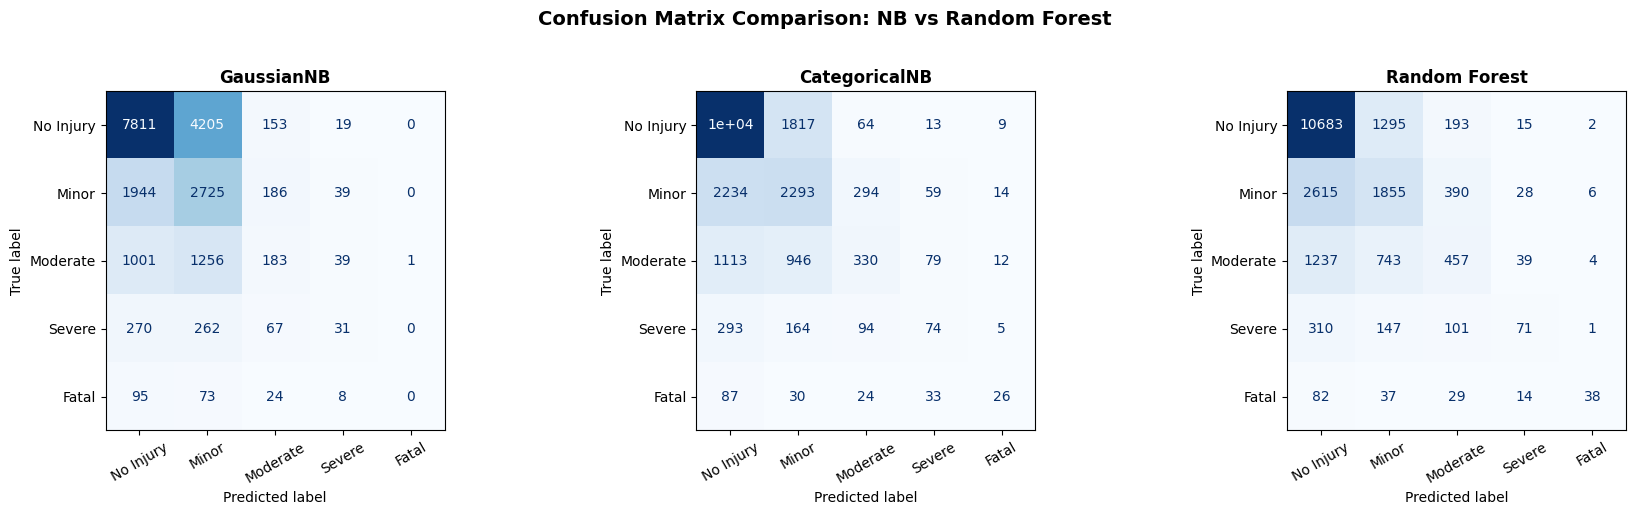

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, [
    ('GaussianNB', y_pred_gnb),
    ('CategoricalNB', y_pred_cnb),
    ('Random Forest', y_pred_rf),
]):
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix Comparison: NB vs Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb_vs_rf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Why Naive Bayes Fails: Theoretical Analysis

### 1. Independence Assumption Violated
The EDA found multiple feature pairs that co-vary strongly:

- **Sobriety × Lighting**: DUI crashes (Sobriety = "Under Influence") disproportionately
  occur at night. These are nearly dependent features — NB treats them as independent,
  effectively double-counting the nighttime DUI signal.
- **Weather × RoadwaySurface**: Rain weather almost perfectly predicts Wet road surface.
  NB multiplies P(Rain | y) × P(Wet | y), which massively over-weights this evidence.
- **CollisionType × PrimaryCollisionFactor**: Pedestrian collisions cluster tightly with
  specific primary factors, violating the independence assumption.

### 2. GaussianNB Distribution Mismatch
GaussianNB models P(feature | class) as a bell curve. For label-encoded categoricals
(e.g., CollisionType encoded 0–7), this fits a Gaussian over an unordered discrete set.
The resulting probability estimates are numerically computed but statistically meaningless.

### 3. CategoricalNB's Feature Gap
CategoricalNB cannot accept continuous inputs. This forces us to drop:
- **Latitude/Longitude**: Removes all location-based signal (road type, intersection risk)
- **Age**: Removes the U-shaped age risk curve identified in EDA
- **VehicleCount**: Removes multi-vehicle collision signal

### 4. No Class Imbalance Handling
RandomForestClassifier has `class_weight='balanced'`, which inversely weights each class
by its frequency, dramatically improving minority-class (Severe, Fatal) recall.
Naive Bayes has no equivalent parameter — it predicts the majority class by default.

### Conclusion
Naive Bayes achieves low macro-F1 on this dataset because: (1) the independence
assumption is violated by multiple correlated feature pairs found in EDA, (2) GaussianNB's
distributional assumption is invalid for categorical features, (3) CategoricalNB cannot
utilize the most spatially and demographically informative continuous features, and
(4) neither variant handles the severe class imbalance present in crash severity data.
Random Forest avoids all four failure modes.